# 05 — Baseline model

I train a logistic regression to predict in-hospital mortality from the 24h features extracted in notebook 04. The aim isn't a strong model — it's a clean, interpretable baseline that I can audit for fairness in the next notebook.

## Methodology choices

- **Logistic regression** with default L2 regularization. Linear, interpretable, no hyperparameter drama.
- **Cross-validation rather than a single train/test split.** With ~50 stays, a 20% test fold would be 10 examples — too noisy to read anything from. K-fold gives me out-of-fold predictions for every stay (every stay is in the test fold exactly once), which is also what the fairness audit needs to cover every subgroup.
- **Features**: clinical only (age + vitals + labs). Gender, race, and insurance are held aside as grouping variables, not model inputs.
- **Acknowledged limitation**: ~43 features for ~50 stays — overparametrized. The model is going to overfit and out-of-fold metrics will be soft. This is a methodology demo on the MIMIC-IV Demo; the same pipeline on full MIMIC will have far more headroom.

## Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    RocCurveDisplay, PrecisionRecallDisplay,
)
from sklearn.calibration import CalibrationDisplay

DATA_DIR = Path("../data")
DERIVED = DATA_DIR / "derived"

RANDOM_STATE = 42

## Load features and define X, y

In [2]:
features = pd.read_csv(DERIVED / "features.csv")
print(f"features: {features.shape}")

# Clinical features only. Drop identifiers, demographics (held for fairness), and the outcome.
held_out_cols = {
    "stay_id", "subject_id", "hadm_id",
    "gender", "race", "insurance", "gender_f",
    "hospital_expire_flag",
}
clinical_cols = [c for c in features.columns if c not in held_out_cols]
print(f"clinical features ({len(clinical_cols)}):")
for c in clinical_cols:
    print(f"  {c}")

features: (85, 51)
clinical features (43):
  anchor_age
  min_dbp
  min_heart_rate
  min_resp_rate
  min_sbp
  min_spo2
  min_temp_c
  max_dbp
  max_heart_rate
  max_resp_rate
  max_sbp
  max_spo2
  max_temp_c
  mean_dbp
  mean_heart_rate
  mean_resp_rate
  mean_sbp
  mean_spo2
  mean_temp_c
  min_bun
  min_creatinine
  min_glucose
  min_hemoglobin
  min_lactate
  min_potassium
  min_sodium
  min_wbc
  max_bun
  max_creatinine
  max_glucose
  max_hemoglobin
  max_lactate
  max_potassium
  max_sodium
  max_wbc
  mean_bun
  mean_creatinine
  mean_glucose
  mean_hemoglobin
  mean_lactate
  mean_potassium
  mean_sodium
  mean_wbc


In [3]:
X = features[clinical_cols].values
y = features["hospital_expire_flag"].values

print(f"X: {X.shape}")
print(f"y: {y.shape}  (positives = {y.sum()} / {len(y)}, rate = {y.mean():.1%})")

X: (85, 43)
y: (85,)  (positives = 7 / 85, rate = 8.2%)


## Pipeline + cross-validated predictions

In [4]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

oof_proba = cross_val_predict(
    pipeline, X, y,
    cv=cv,
    method="predict_proba",
)[:, 1]

oof_pred = (oof_proba >= 0.5).astype(int)

print("Cross-validated predictions ready.")
print(f"  proba range: [{oof_proba.min():.3f}, {oof_proba.max():.3f}]")
print(f"  predicted positive rate: {oof_pred.mean():.1%}  (true: {y.mean():.1%})")

Cross-validated predictions ready.
  proba range: [0.000, 0.862]
  predicted positive rate: 4.7%  (true: 8.2%)


## Overall performance

In [5]:
auc_roc = roc_auc_score(y, oof_proba)
auc_pr = average_precision_score(y, oof_proba)

print(f"AUC-ROC: {auc_roc:.3f}")
print(f"AUC-PR:  {auc_pr:.3f}  (baseline = {y.mean():.3f})")
print()
print("Classification report (threshold = 0.5):")
print(classification_report(y, oof_pred, target_names=["Survived", "Died"], zero_division=0))

AUC-ROC: 0.284
AUC-PR:  0.103  (baseline = 0.082)

Classification report (threshold = 0.5):
              precision    recall  f1-score   support

    Survived       0.93      0.96      0.94        78
        Died       0.25      0.14      0.18         7

    accuracy                           0.89        85
   macro avg       0.59      0.55      0.56        85
weighted avg       0.87      0.89      0.88        85



In [6]:
cm = confusion_matrix(y, oof_pred)
cm_df = pd.DataFrame(cm, index=["Survived", "Died"], columns=["Pred. Survived", "Pred. Died"])
cm_df

,Pred. Survived,Pred. Died
Survived,75,3
Died,6,1


## ROC and PR curves

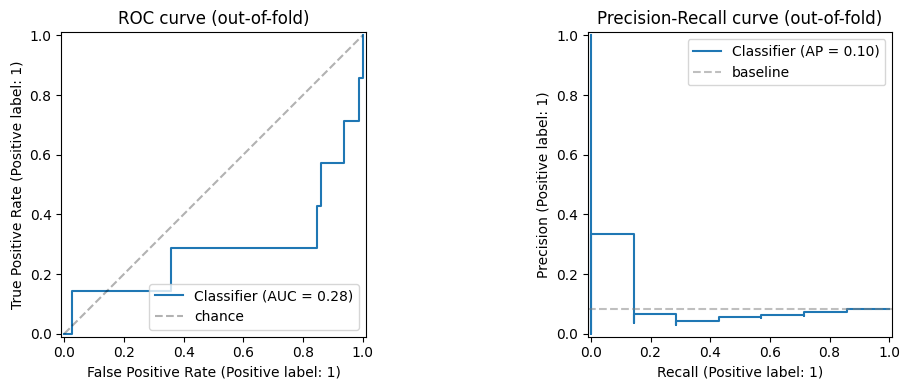

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

RocCurveDisplay.from_predictions(y, oof_proba, ax=axes[0])
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3, label="chance")
axes[0].set_title("ROC curve (out-of-fold)")
axes[0].legend(loc="lower right")

PrecisionRecallDisplay.from_predictions(y, oof_proba, ax=axes[1])
axes[1].axhline(y.mean(), linestyle="--", color="gray", alpha=0.5, label="baseline")
axes[1].set_title("Precision-Recall curve (out-of-fold)")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

## Calibration

A well-calibrated model assigns probabilities that match observed frequencies (a 0.7 predicted probability corresponds to ~70% empirical positivity). With this sample size the reliability diagram will be jagged — read it directionally.

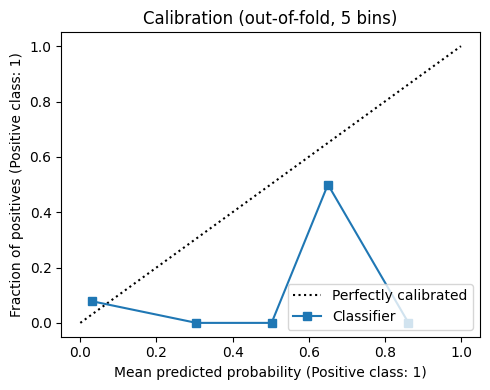

In [8]:
fig, ax = plt.subplots(figsize=(5, 4))
CalibrationDisplay.from_predictions(y, oof_proba, n_bins=5, ax=ax)
ax.set_title("Calibration (out-of-fold, 5 bins)")
plt.tight_layout()
plt.show()

## Model coefficients

Re-fitting on the full cohort to look at coefficients (these say which features drive predictions, not which features are *causal*). After standardization, coefficients are comparable across features.

In [9]:
pipeline.fit(X, y)
coefs = pipeline.named_steps["clf"].coef_[0]

coef_df = (
    pd.DataFrame({"feature": clinical_cols, "coef": coefs})
    .assign(abs_coef=lambda d: d["coef"].abs())
    .sort_values("abs_coef", ascending=False)
    .drop(columns="abs_coef")
    .reset_index(drop=True)
)
coef_df.head(15)

,feature,coef
0,max_wbc,0.935942
1,mean_heart_rate,0.888932
2,min_wbc,-0.623177
3,max_sbp,0.592290
4,min_temp_c,-0.572227
5,mean_resp_rate,0.549918
6,min_hemoglobin,0.523056
7,min_potassium,0.489423
8,min_spo2,0.436899
9,mean_dbp,-0.393983


## Save predictions for the fairness audit

In [10]:
predictions = features[[
    "stay_id", "subject_id", "anchor_age", "gender", "race", "insurance",
    "hospital_expire_flag",
]].copy()
predictions["pred_proba"] = oof_proba
predictions["pred_label"] = oof_pred

out_path = DERIVED / "predictions.csv"
predictions.to_csv(out_path, index=False)
print(f"saved to {out_path}")
print(f"shape: {predictions.shape}")

saved to ../data/derived/predictions.csv
shape: (85, 9)


## Takeaways

- The model is overparametrized for this sample size, so AUC and calibration are soft. The interesting question isn't *how well* it does — it's *how its errors are distributed across subgroups*, which is the next notebook.
- The coefficient table is a sanity check more than a finding: clinically plausible signs would be reassuring; large jumps would warrant a look at imputation.
- The same pipeline drops straight into full MIMIC-IV with more data and proper regularization tuning.

Next (notebook 06): stratify performance across demographic subgroups, compute fairness metrics, and discuss what the gaps mean — or don't, at this sample size.